In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("C:/Users/TECHMATE DZ/Flight_Price_Prediction/Clean_Dataset.csv")

In [3]:
data

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [4]:
data.airline.value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [5]:
data.source_city.value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [6]:
data.destination_city.value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

In [7]:
data.departure_time.value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [8]:
data.arrival_time.value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

In [9]:
data.stops.value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [10]:
data['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

In [11]:
data['duration'].min()

np.float64(0.83)

In [12]:
data['duration'].max()

np.float64(49.83)

In [13]:
data['duration'].median()

np.float64(11.25)

In [14]:
data = data.drop('Unnamed: 0', axis=1)
data = data.drop('flight', axis=1)

data['class'] = data['class'].apply(lambda x: 1 if x == 'Business' else 0)

In [15]:
data.stops = pd.factorize(data.stops)[0]

In [16]:
data = data.join(pd.get_dummies(data.airline, prefix='airline')).drop('airline', axis=1)
data = data.join(pd.get_dummies(data.source_city, prefix='source')).drop('source_city', axis=1)
data = data.join(pd.get_dummies(data.destination_city, prefix='dest')).drop('destination_city', axis=1)
data = data.join(pd.get_dummies(data.arrival_time, prefix='arrival')).drop('arrival_time', axis=1)
data = data.join(pd.get_dummies(data.departure_time, prefix='departure')).drop('departure_time', axis=1)

In [17]:
data

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,departure_Afternoon,departure_Early_Morning,departure_Evening,departure_Late_Night,departure_Morning,departure_Night
0,0,0,2.17,1,5953,False,False,False,False,True,...,False,False,False,True,False,False,True,False,False,False
1,0,0,2.33,1,5953,False,False,False,False,True,...,False,False,True,False,False,True,False,False,False,False
2,0,0,2.17,1,5956,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,2.25,1,5955,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,0,2.33,1,5955,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
300149,1,1,10.42,49,77105,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
300150,1,1,13.83,49,79099,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
300151,1,1,10.00,49,81585,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False


## Training Regression Model

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

x, y = data.drop('price', axis = 1), data.price

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)

In [20]:
reg = RandomForestRegressor(n_jobs=-1)
reg.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
reg.score(x_test, y_test)

0.9853512613806473

In [22]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_RF = reg.predict(x_test)
print('R2:', r2_score(y_test, y_pred_RF))
print('MAE:', mean_absolute_error(y_test, y_pred_RF))
print('MSE:', mean_squared_error(y_test, y_pred_RF))
print('RMSE:', math.sqrt(mean_squared_error(y_test, y_pred_RF)))


R2: 0.9853512613806473
MAE: 1071.2646347473058
MSE: 7573084.225715103
RMSE: 2751.9237318129117


Text(0.5, 1.0, 'Prediction VS Actual Price')

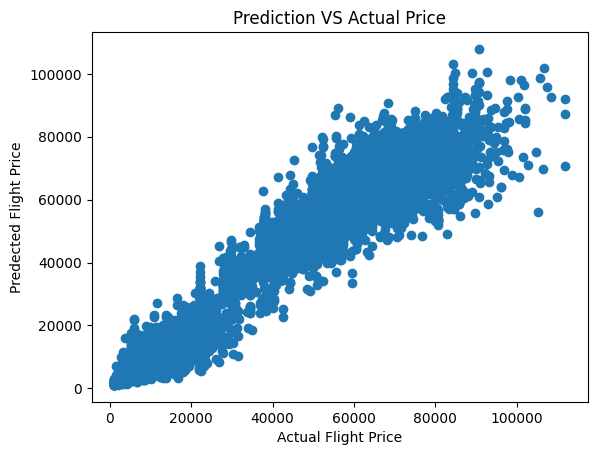

In [23]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_RF)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predected Flight Price')
plt.title('Prediction VS Actual Price')

In [24]:
data.price.describe()

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

In [25]:
importances = dict(zip(reg.feature_names_in_, reg.feature_importances_))
sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=True)

In [26]:
sorted_importances

[('class', np.float64(0.8798400077805609)),
 ('duration', np.float64(0.05754447502294426)),
 ('days_left', np.float64(0.018499889493656527)),
 ('airline_Air_India', np.float64(0.005358845769117891)),
 ('airline_Vistara', np.float64(0.004595884397411984)),
 ('source_Delhi', np.float64(0.00354886151148784)),
 ('dest_Delhi', np.float64(0.0033271992645928874)),
 ('source_Mumbai', np.float64(0.002248949142008997)),
 ('dest_Kolkata', np.float64(0.0019081821627291492)),
 ('dest_Mumbai', np.float64(0.0018981936125124334)),
 ('stops', np.float64(0.001897434503467486)),
 ('source_Kolkata', np.float64(0.0017387964107332687)),
 ('arrival_Evening', np.float64(0.00160254213261196)),
 ('dest_Hyderabad', np.float64(0.0014616758712933432)),
 ('source_Hyderabad', np.float64(0.001334107611322984)),
 ('dest_Bangalore', np.float64(0.0013146535745196173)),
 ('arrival_Night', np.float64(0.0011744572353564243)),
 ('source_Bangalore', np.float64(0.001106071233018723)),
 ('departure_Evening', np.float64(0.00105

In [27]:
data.days_left.describe()

count    300153.000000
mean         26.004751
std          13.561004
min           1.000000
25%          15.000000
50%          26.000000
75%          38.000000
max          49.000000
Name: days_left, dtype: float64

<BarContainer object of 10 artists>

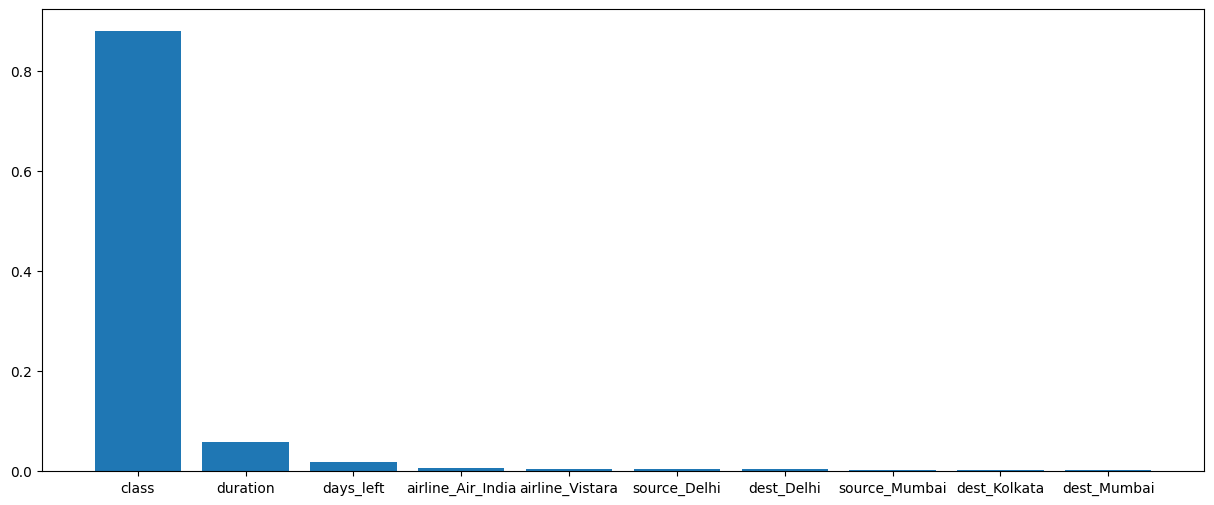

In [28]:
plt.figure(figsize=(15, 6))
plt.bar([x[0] for x in sorted_importances[:10]], [x[1] for x in sorted_importances[:10]])

In [29]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
'n_estimators': randint(100, 300),
'max_depth': [None, 10, 20, 30, 40, 50],
'min_samples_split': randint(2, 11),
'min_samples_leaf': randint(1, 5),
'max_features': [1.0, 'sqrt']

}

reg = RandomForestRegressor(n_jobs=-1)
random_search = RandomizedSearchCV(estimator=reg, param_distributions=param_dist, n_iter=5, cv=3,
                                   scoring='neg_mean_squared_error', verbose=2, random_state=10, n_jobs=-1)

random_search.fit(x_train, y_train)
best_regressor = random_search.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


In [30]:
best_regressor.score(x_test, y_test)

0.9862468367980015

In [31]:
import math
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_RS = best_regressor.predict(x_test)
print('R2:', r2_score(y_test, y_pred_RS))
print('MAE:', mean_absolute_error(y_test, y_pred_RS))
print('MSE:', mean_squared_error(y_test, y_pred_RS))
print('RMSE:', math.sqrt(mean_squared_error(y_test, y_pred_RS)))


R2: 0.9862468367980015
MAE: 1083.8866791189046
MSE: 7110090.909884938
RMSE: 2666.475372075455


Text(0.5, 1.0, 'Prediction VS Actual Price')

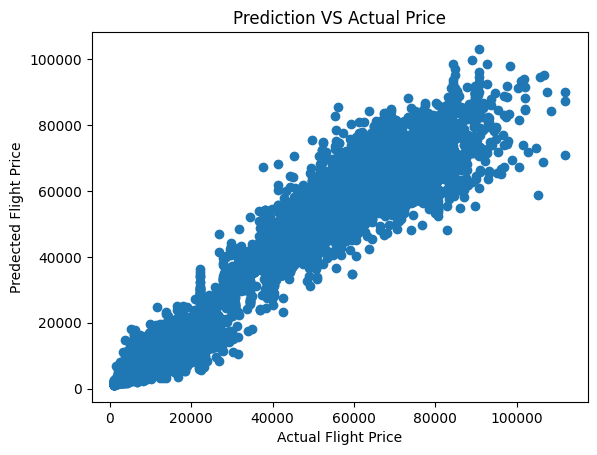

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_RS)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predected Flight Price')
plt.title('Prediction VS Actual Price')

## Training Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression

reg_lr = LinearRegression()

reg_lr.fit(x_train, y_train)
y_pred_lr = reg_lr.predict(x_test)

In [35]:
print("R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("RMSE:", math.sqrt(mean_squared_error(y_test, y_pred_lr)))

R2: 0.9103512065895966
MAE: 4518.041590959491
MSE: 46346506.745214924
RMSE: 6807.8268739161485


Text(0.5, 1.0, 'Prediction VS Actual Price')

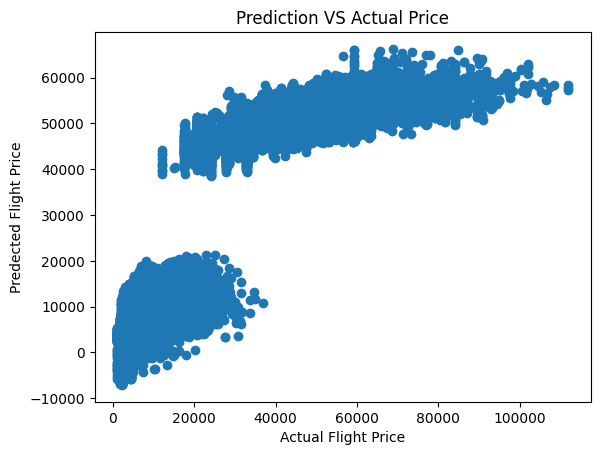

In [36]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predected Flight Price')
plt.title('Prediction VS Actual Price')

## Training Ploynomial Regression

In [37]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly = PolynomialFeatures(degree=2)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
reg_poly = LinearRegression()
reg_poly.fit(x_train_poly, y_train)
y_pred_poly = reg_poly.predict(x_test_poly)




In [38]:
print("R2:", r2_score(y_test, y_pred_poly))
print("MAE:", mean_absolute_error(y_test, y_pred_poly))
print("MSE:", mean_squared_error(y_test, y_pred_poly))
print("RMSE:", math.sqrt(mean_squared_error(y_test, y_pred_poly)))

R2: 0.9498761565106537
MAE: 3264.6597364766576
MSE: 25912953.894876454
RMSE: 5090.476784631913


Text(0.5, 1.0, 'Prediction VS Actual Price')

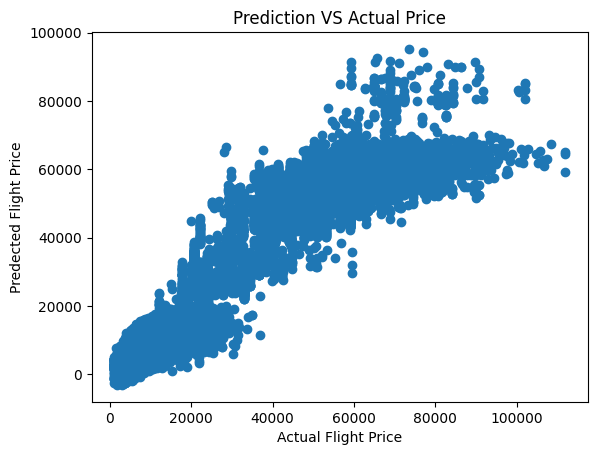

In [39]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_poly)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predected Flight Price')
plt.title('Prediction VS Actual Price')

## Training Gradiant Boosting

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

reg_gb = GradientBoostingRegressor(random_state=10)
reg_gb.fit(x_train, y_train)
y_pred_gb = reg_gb.predict(x_test)

In [41]:
print("R2:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("RMSE:", math.sqrt(mean_squared_error(y_test, y_pred_gb)))

R2: 0.9528251479115254
MAE: 2924.031209678808
MSE: 24388388.480745357
RMSE: 4938.460132545909


Text(0.5, 1.0, 'Prediction VS Actual Price')

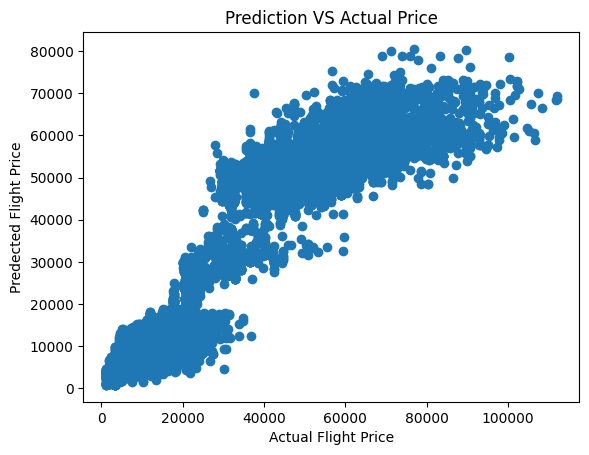

In [42]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_gb)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predected Flight Price')
plt.title('Prediction VS Actual Price')

## Training XGBoost

In [43]:
from xgboost import XGBRegressor
reg_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=10
)

reg_xgb.fit(x_train, y_train)
y_pred_xgb = reg_xgb.predict(x_test)

In [44]:
print("R2:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("MSE:", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", math.sqrt(mean_squared_error(y_test, y_pred_xgb)))

R2: 0.9707981944084167
MAE: 2213.1337890625
MSE: 15096720.0
RMSE: 3885.4497809134014


Text(0.5, 1.0, 'Prediction VS Actual Price')

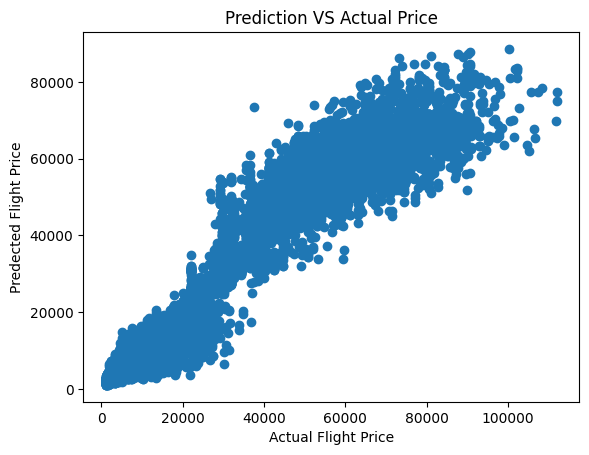

In [45]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_xgb)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predected Flight Price')
plt.title('Prediction VS Actual Price')

## Comparing Models

In [46]:
results = {}
def add_results(name, y_test, y_pred):
    results[name] = {
        'R2': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': math.sqrt(mean_squared_error(y_test, y_pred))
    }
add_results('Random Forest', y_test, y_pred_RF)
add_results('Randomized SearchCV', y_test, y_pred_RS)
add_results('Linear Regression', y_test, y_pred_lr)
add_results('Polynomial Regression', y_test, y_pred_poly)
add_results('Gradient Boosting', y_test, y_pred_gb)
add_results('XGBoost', y_test, y_pred_xgb)

results_df = pd.DataFrame(results).T.reset_index()
results_df.rename(columns={'index': 'Model'}, inplace=True)


results_df

,Model,R2,MAE,MSE,RMSE
0,Random Forest,0.985351,1071.264635,7.573084e+06,2751.923732
1,Randomized SearchCV,0.986247,1083.886679,7.110091e+06,2666.475372
2,Linear Regression,0.910351,4518.041591,4.634651e+07,6807.826874
3,Polynomial Regression,0.949876,3264.659736,2.591295e+07,5090.476785
4,Gradient Boosting,0.952825,2924.031210,2.438839e+07,4938.460133
5,XGBoost,0.970798,2213.133789,1.509672e+07,3885.449781


In [47]:
results_df.sort_values('R2', ascending=False)

,Model,R2,MAE,MSE,RMSE
1,Randomized SearchCV,0.986247,1083.886679,7.110091e+06,2666.475372
0,Random Forest,0.985351,1071.264635,7.573084e+06,2751.923732
5,XGBoost,0.970798,2213.133789,1.509672e+07,3885.449781
4,Gradient Boosting,0.952825,2924.031210,2.438839e+07,4938.460133
3,Polynomial Regression,0.949876,3264.659736,2.591295e+07,5090.476785
2,Linear Regression,0.910351,4518.041591,4.634651e+07,6807.826874


In [48]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'max_depth': 30, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 257}


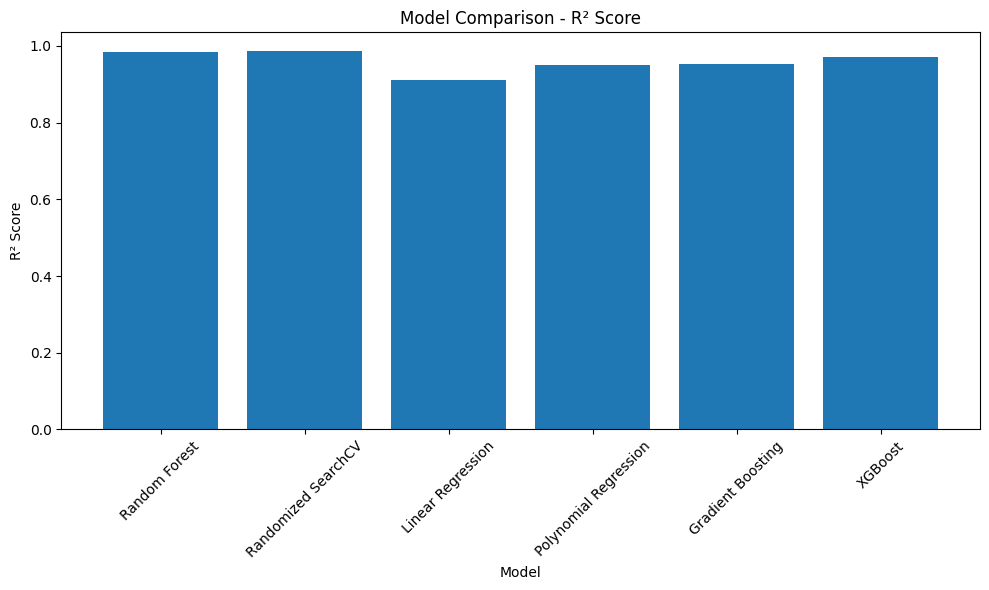

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(results_df['Model'], results_df['R2'])

plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Model Comparison - R² Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

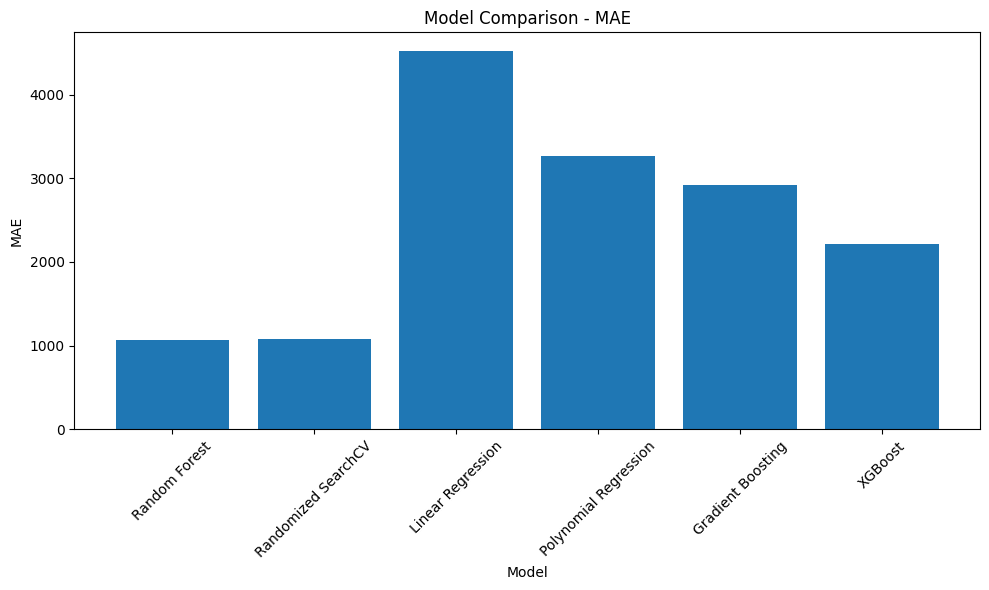

In [50]:
plt.figure(figsize=(10, 6))

plt.bar(results_df['Model'], results_df['MAE'])

plt.xlabel('Model')
plt.ylabel('MAE')
plt.title('Model Comparison - MAE')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
best_regressor

,n_estimators,257
,criterion,'squared_error'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
y_pred_final = best_regressor.predict(x_test)

print("Final Model Performance")
print("R2:", r2_score(y_test, y_pred_final))
print("MAE:", mean_absolute_error(y_test, y_pred_final))
print("MSE:", mean_squared_error(y_test, y_pred_final))
print("RMSE:", math.sqrt(mean_squared_error(y_test, y_pred_final)))

Final Model Performance
R2: 0.9862468367980015
MAE: 1083.8866791189046
MSE: 7110090.909884938
RMSE: 2666.475372075455


In [53]:
importances = pd.Series(
    best_regressor.feature_importances_,
    index=x_train.columns
)

importances = importances.sort_values(ascending=False)

importances.head(10)

class                0.883277
duration             0.056881
days_left            0.016538
airline_Air_India    0.005313
airline_Vistara      0.004695
source_Delhi         0.003616
dest_Delhi           0.003376
source_Mumbai        0.002265
dest_Mumbai          0.001881
dest_Kolkata         0.001873
dtype: float64

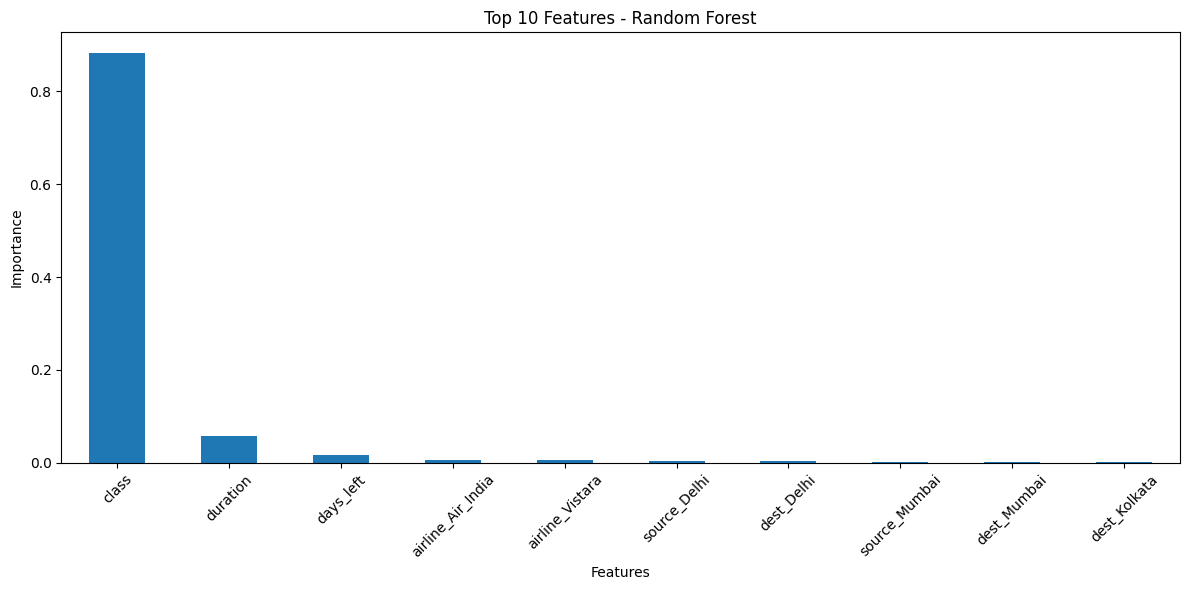

In [54]:
plt.figure(figsize=(12, 6))

importances.head(10).plot(kind='bar')

plt.title('Top 10 Features - Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
import joblib

joblib.dump(best_regressor, 'Models/flight_price_model.pkl')

['Models/flight_price_model.pkl']